In [1]:
import torch
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive
import os

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.3 MB/s eta 0:00:00


In [2]:
def analyze_client_data(file_path):
    # Kiểm tra file có tồn tại không
    if not os.path.exists(file_path):
        print(f"Lỗi: Không tìm thấy file tại {file_path}")
        return
    #  Load file .pt
    # Lưu ý: Các file .pt tạo ra chứa đối tượng Subset của PyTorch
    dataset = torch.load(file_path, weights_only=False)

    print(f"=== THỐNG KÊ DỮ LIỆU: {os.path.basename(file_path)} ===")
    print(f"Tổng số mẫu: {len(dataset)}")

    # Đếm số lượng nhãn và lưu lại ảnh minh họa
    label_counts = Counter()
    sample_images = {} # Lưu {nhãn: ảnh_đầu_tiên_tìm_thấy}

    for img, label in dataset:
        label_counts[label] += 1
        # Nếu nhãn này chưa có ảnh minh họa thì lưu lại
        if label not in sample_images:
            sample_images[label] = img

    # Sắp xếp nhãn theo thứ tự tăng dần
    sorted_labels = sorted(label_counts.keys())

    #  Hiển thị bảng thống kê
    print("\nChi tiết phân bổ nhãn:")
    for label in sorted_labels:
        print(f" - Nhãn {label}: {label_counts[label]} mẫu")

    # Hiển thị ảnh minh họa để chứng minh
    print("\nĐang hiển thị ảnh minh họa cho từng nhãn...")
    num_labels = len(sorted_labels)
    plt.figure(figsize=(15, 3))

    for i, label in enumerate(sorted_labels):
        plt.subplot(1, num_labels, i + 1)
        # Chuyển tensor về dạng (28, 28) để vẽ
        img_to_show = sample_images[label].squeeze()
        plt.imshow(img_to_show, cmap='gray')
        plt.title(f"Nhãn: {label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


=== THỐNG KÊ DỮ LIỆU: client_0_data.pt ===
Tổng số mẫu: 15000

Chi tiết phân bổ nhãn:
 - Nhãn 0: 5923 mẫu
 - Nhãn 1: 6742 mẫu
 - Nhãn 2: 2335 mẫu

Đang hiển thị ảnh minh họa cho từng nhãn...


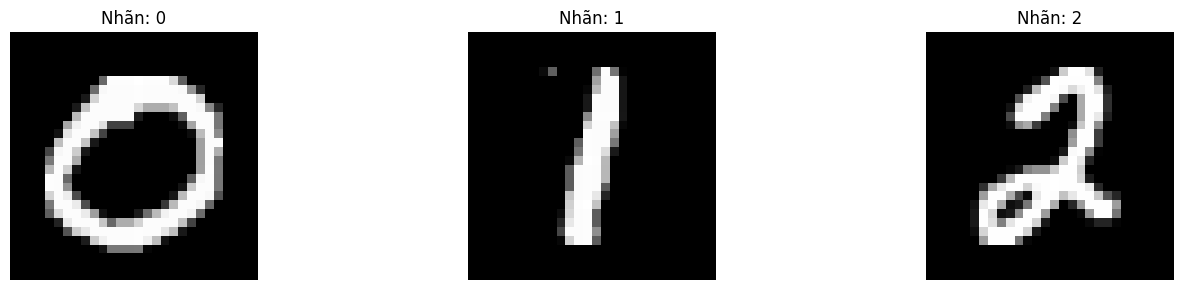

In [3]:
# --- CHẠY KIỂM TRA ---
PATH_TO_FILE = '/content/drive/MyDrive/Dataset FL DP/client_0_data.pt'
analyze_client_data(PATH_TO_FILE)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [6]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load toàn bộ data của Client 0
full_local_data = torch.load(PATH_TO_FILE, weights_only=False)

# Chia nội bộ: 80% Train, 10% Val, 10% Test (Nội bộ)
train_size = int(0.8 * len(full_local_data))
val_size = int(0.1 * len(full_local_data))
test_local_size = len(full_local_data) - train_size - val_size

train_ds, val_ds, test_local_ds = random_split(full_local_data, [train_size, val_size, test_local_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_local_loader = DataLoader(test_local_ds, batch_size=32)
print(f"--- Client 0 sở hữu {len(full_local_data)} mẫu.")
print(f"--- Đã chia: Train({len(train_ds)}), Val({len(val_ds)}), Test nội bộ({len(test_local_ds)})")

--- Client 0 sở hữu 15000 mẫu.
--- Đã chia: Train(12000), Val(1500), Test nội bộ(1500)


In [7]:
model = Net().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 6):
    model.train()
    for data, target in train_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad(); output = model(data)
        loss = criterion(output, target); loss.backward(); optimizer.step()

    # Val nội bộ
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data); pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
    print(f"Epoch {epoch} - Độ chính xác trên tập Val nội bộ: {100. * correct / len(val_ds):.2f}%")

Epoch 1 - Độ chính xác trên tập Val nội bộ: 99.60%
Epoch 2 - Độ chính xác trên tập Val nội bộ: 99.40%
Epoch 3 - Độ chính xác trên tập Val nội bộ: 99.67%
Epoch 4 - Độ chính xác trên tập Val nội bộ: 99.80%
Epoch 5 - Độ chính xác trên tập Val nội bộ: 99.67%


[*] Đang đánh giá mô hình trên 1500 mẫu test nội bộ...


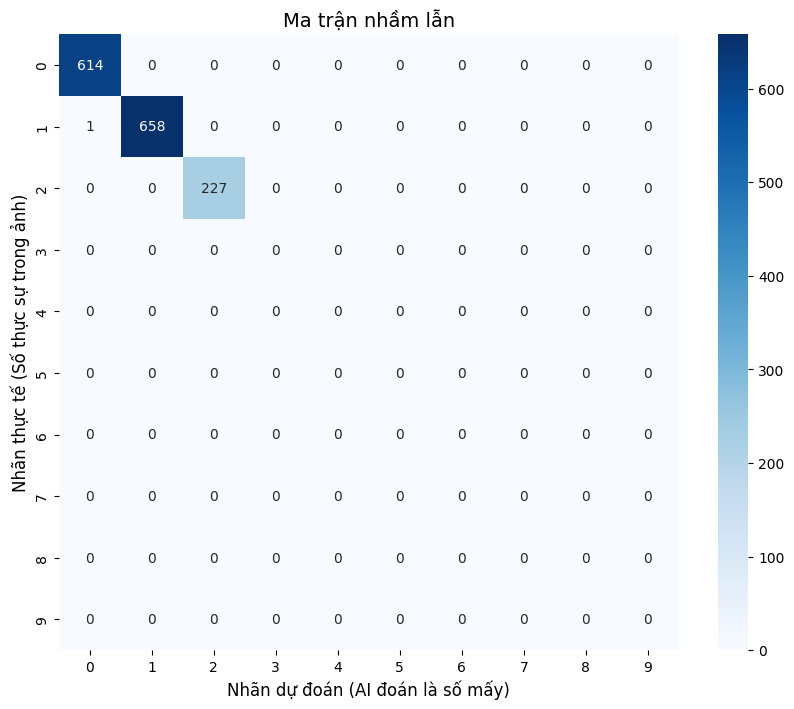


--- Báo cáo chi tiết hiệu năng trên các nhãn ĐÃ HỌC:
              precision    recall  f1-score   support

        Số 0     0.9984    1.0000    0.9992       614
        Số 1     1.0000    0.9985    0.9992       659
        Số 2     1.0000    1.0000    1.0000       227

    accuracy                         0.9993      1500
   macro avg     0.9995    0.9995    0.9995      1500
weighted avg     0.9993    0.9993    0.9993      1500



In [12]:
model.eval()
all_preds_local = []
all_targets_local = []

#. Thu thập dự đoán từ tập Test NỘI BỘ
print(f"[*] Đang đánh giá mô hình trên {len(test_local_ds)} mẫu test nội bộ...")
with torch.no_grad():
    for data, target in test_local_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        output = model(data)
        preds = output.argmax(dim=1)
        all_preds_local.extend(preds.cpu().numpy())
        all_targets_local.extend(target.cpu().numpy())

# Tính toán Ma trận nhầm lẫn
cm_local = confusion_matrix(all_targets_local, all_preds_local, labels=range(10))

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(10, 8))
# Dùng annot=True để hiện số lượng mẫu, fmt='d' cho số nguyên, cmap màu xanh đậm
sns.heatmap(cm_local, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.title(f"Ma trận nhầm lẫn", fontsize=14)
plt.xlabel("Nhãn dự đoán (AI đoán là số mấy)", fontsize=12)
plt.ylabel("Nhãn thực tế (Số thực sự trong ảnh)", fontsize=12)
plt.grid(False)
plt.show()

# In báo cáo
# Cần trích xuất target_names phù hợp
labels_present_local = sorted(list(set(all_targets_local)))
target_names_present = [f"Số {l}" for l in labels_present_local]

print("\n--- Báo cáo chi tiết hiệu năng trên các nhãn ĐÃ HỌC:")

from sklearn.metrics import classification_report
print(classification_report(all_targets_local, all_preds_local, labels=labels_present_local, target_names=target_names_present, digits=4))

In [14]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
full_mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform)
full_test_loader = DataLoader(full_mnist_test, batch_size=1000)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.58MB/s]



--- LẦN KIỂM TRA THỨ 1 ---


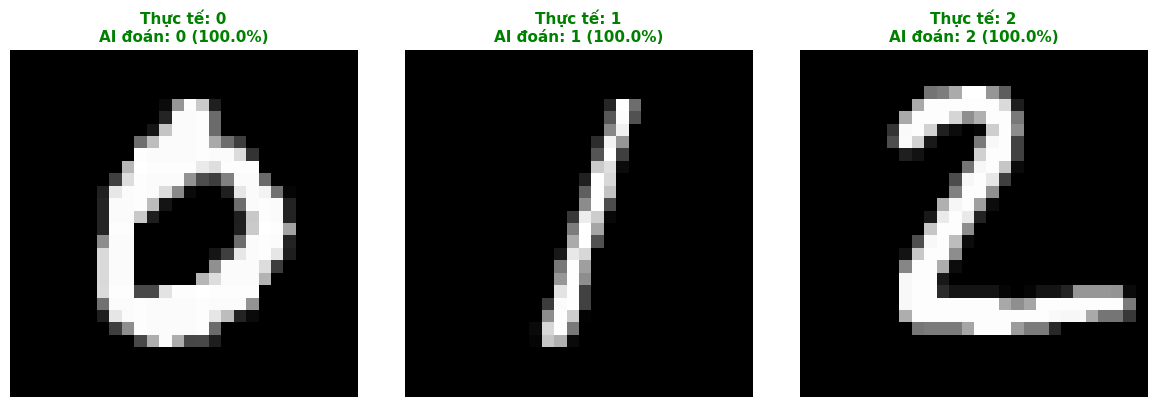


--- LẦN KIỂM TRA THỨ 2 ---


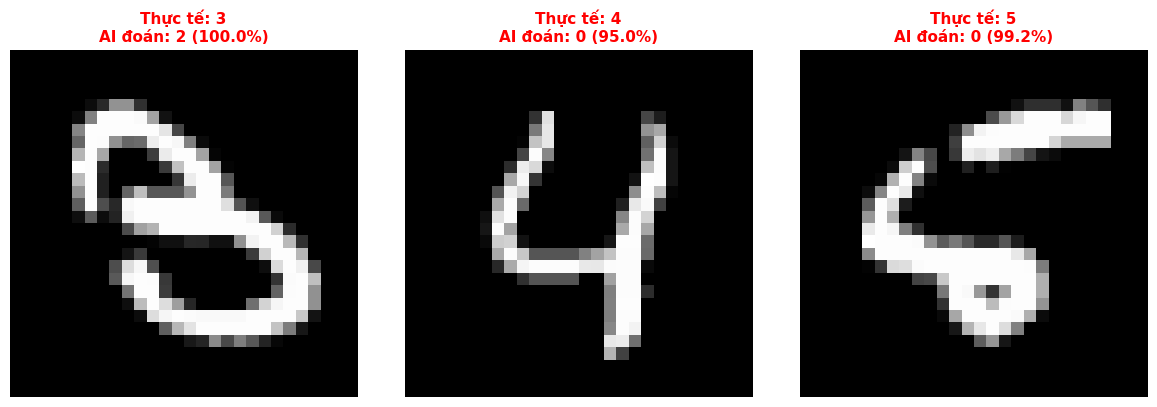


--- LẦN KIỂM TRA THỨ 3 ---


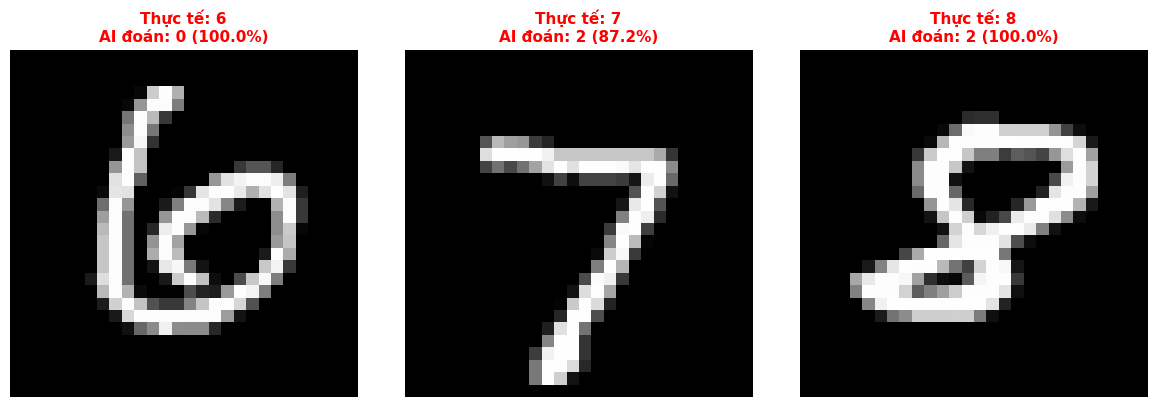

In [15]:
import torch.nn.functional as F

def run_test_batches(model, full_dataset):
    model.eval()

    # Thu thập 9 mẫu ảnh
    known_labels = [0, 1, 2]
    other_labels = [3, 4, 5, 6, 7, 8, 9]

    test_samples = []

    # Lấy 3 hình có nhãn 0, 1, 2
    for label in known_labels:
        idx = (full_dataset.targets == label).nonzero(as_tuple=True)[0][0]
        test_samples.append(full_dataset[idx])

    # Lấy 6 hình có nhãn khác (mỗi nhãn 1 hình từ 3 đến 8)
    for label in range(3, 9):
        idx = (full_dataset.targets == label).nonzero(as_tuple=True)[0][0]
        test_samples.append(full_dataset[idx])

    # Thực hiện 3 lần kiểm tra, mỗi lần 3 hình
    for batch_idx in range(3):
        start_idx = batch_idx * 3
        batch_samples = test_samples[start_idx : start_idx + 3]

        print(f"\n--- LẦN KIỂM TRA THỨ {batch_idx + 1} ---")
        plt.figure(figsize=(12, 4))

        for i, (img, label) in enumerate(batch_samples):
            # Dự đoán
            with torch.no_grad():
                output = model(img.unsqueeze(0).to(DEVICE))
                prediction = output.argmax(dim=1).item()
                probs = F.softmax(output, dim=1)
                confidence = probs[0][prediction] * 100

            # Hiển thị
            plt.subplot(1, 3, i + 1)
            plt.imshow(img.squeeze(), cmap='gray')

            # Đổi màu tiêu đề: Xanh nếu đoán đúng, Đỏ nếu đoán sai
            color = 'green' if prediction == label else 'red'

            plt.title(f"Thực tế: {label}\nAI đoán: {prediction} ({confidence:.1f}%)",
                      color=color, fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Chạy kiểm tra
run_test_batches(model, full_mnist_test)